Import Libraries

In [39]:
import jax
import flax
import optax
from jax import lax, random, numpy as jnp
from jax import random, grad, vmap, hessian, jacfwd, jit
from jax import config
from flax import linen as nn

import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors

# choose GPU
import os
from tqdm.auto import tqdm
#os.environ['CUDA_VISIBLE_DEVICES'] = '1'
config.update("jax_enable_x64", True)
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'

In [40]:
n_gpu = len(jax.devices())
jax.devices()

[CudaDevice(id=0)]

13. 2D Poisson Equation

        (u_xx + u_yy) = s

#### data_T20_S30_G50_reduced: 
Column 0 (x): The x-coordinate on the 2D spatial grid.
Column 1 (y): The y-coordinate on the 2D spatial grid.
Column 2 (s): The source term at that specific (x,y) coordinate.
Column 3 (u_sim): The ground truth solution (u) at that (x,y) coordinate.

#### data_T20_S30_G50: 
We need to swap x and y labels at the very start because Column 0 contains the Y-grid and Column 1 contains the X-grid.

In [41]:
# For Collab
# dat = np.loadtxt('/content/drive/MyDrive/Colab Notebooks/data/data_T20_S30_G50_reduced.dat', skiprows=1, delimiter=',')
DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/data/"

# For PC
DATA_DIR = Path.cwd().parent.parent / "data"

In [42]:
DATA_FILE = DATA_DIR / "data_T20_S30_G50_reduced.dat"
df = pd.read_csv(DATA_FILE, skiprows=1, header=None, names=['x', 'y', 's', 'u'])
df.head()

,x,y,s,u
0,0.5,0.5,0.0,-2.915824e-07
1,0.5,1.5,0.0,2.917193e-07
2,0.5,2.5,0.0,-2.914012e-07
3,0.5,3.5,0.0,2.918156e-07
4,0.5,4.5,0.0,-2.911721e-07


In [43]:
DATA_FILE = DATA_DIR / "data_T20_S30_G50.dat"
df = pd.read_csv(DATA_FILE, skiprows=1, header=None, names=['x', 'y', 's', 'u'])
df.head()

,x,y,s,u
0,0.5,0.5,0.0,-2.915824e-07
1,1.5,0.5,0.0,2.917193e-07
2,2.5,0.5,0.0,-2.914012e-07
3,3.5,0.5,0.0,2.918156e-07
4,4.5,0.5,0.0,-2.911721e-07


In [44]:
DATA_FILE = DATA_DIR / "data_T20_S30_G50_reduced.dat"

dat = np.loadtxt(DATA_FILE, skiprows=1, delimiter=',')
print (dat.shape)

# swap header for non reduced
if DATA_FILE == DATA_DIR / "data_T20_S30_G50.dat":
    dat[:, [0, 1]] = dat[:, [1, 0]]

# crop to focus on area of interest in the grid
dat = dat[(dat[:,1] > 150) & (dat[:,1] < 350)] # selects all rows where the y-coordinate falls strictly between 150 and 350

# Calculate dimensions
nx = len(np.unique(dat[:, 0])) # take every row in x col 
ny = len(np.unique(dat[:, 1])) # take every row in y col

print(dat.shape)
print(f"Grid dimensions: nx={nx}, ny={ny}")
print(np.unique(dat[:,0]).shape, np.unique(dat[:,1]).shape) # unique coordinate values along each individual axis

x_l, x_u, y_l, y_u = np.unique(dat[:,0]).min(), np.unique(dat[:,0]).max(), np.unique(dat[:,1]).min(), np.unique(dat[:,1]).max()
ext = [x_l, x_u, y_l, y_u] # plot boundary
print(ext)

(122880, 4)
(48000, 4)
Grid dimensions: nx=240, ny=200
(240,) (200,)
[np.float64(0.5), np.float64(239.5), np.float64(150.5), np.float64(349.5)]


Text(0.5, 1.0, 'Solution')

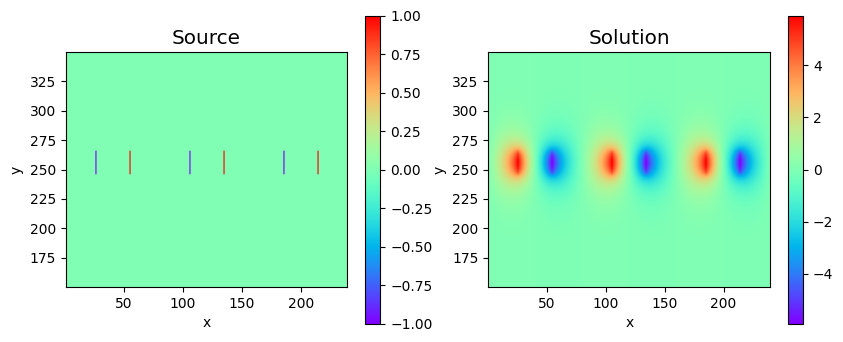

In [45]:
"""
Plot the system with boundaries as the perimeter of the plot
"""
# Source
fig = plt.figure(figsize=(10, 4))
ax1 = fig.add_subplot(1,2,1)
s_plot = dat[:,2].reshape(nx, ny).T
mesh2 = plt.imshow(s_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
plt.colorbar(mesh2); plt.xlabel('x'); plt.ylabel('y')
plt.title('Source', fontsize='x-large')

# Solution
ax1 = fig.add_subplot(1,2,2)
s_plot = dat[:,3].reshape(nx, ny).T
mesh2 = plt.imshow(s_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
plt.colorbar(mesh2); plt.xlabel('x'); plt.ylabel('y')
plt.title('Solution', fontsize='x-large')

In [46]:
# training data - split into spatial input (x, y), source term s, and ground truth (u_sim)
dat = jnp.array(dat)
x, y, s, u_sim = dat[:,0].reshape(-1, 1), dat[:,1].reshape(-1, 1), dat[:,2].reshape(-1, 1), dat[:,3].reshape(-1, 1)
"""
Here, we get our boundary condition masks so that we can easily reference these coordinates later

Dirichlet boundary conditions are used when we know the exact and fixed value of the solution at the boundaries.
Our specific problem uses Neumann (rate of change) and Periodic (x_u => x_l) boundaries instead.
"""

# Neumann Boundaries (Top and Bottom edges)
bc_n = ((y == y_l) | (y == y_u)).flatten()
print('Neumann BC: #sample = %d'%bc_n.sum())

# Boundary Conditions (bc), Periodic upper (pu) and Periodic  lower (pl)
bc_pl, bc_pu = ((x == x_l)).flatten(), ((x == x_u)).flatten()
print('Periodic BC: #sample = %d %d'%(bc_pl.sum(), bc_pu.sum()))

# bc_d = ((y == y_l) | (y == y_u) | (x == x_l) | (x == x_u)).flatten()
# print ('Dirichlet BC: #sample = %d'%bc_d.sum())

# Boundary points for mini-batching
x_n, y_n = x[bc_n], y[bc_n]
x_pl, y_pl = x[bc_pl], y[bc_pl]
x_pu, y_pu = x[bc_pu], y[bc_pu]

Neumann BC: #sample = 480
Periodic BC: #sample = 200 200


FrPINN

In [47]:
"""construct randomization B-PINN for linear/nonlinear ODE/PDEs"""

# get_features: normalize x and y, multiply them by random weights each and add a random bias
@jit
def get_f(x, y, weights):
    # we randomly generate hidden features (the weights will be created in compute_ls_ntask() where the first 9 are normally distributed and the next 9 are uniformly distributed)
    h1 = (x - 125.) / 100. * weights[0] + (y - 250.) / 100. * weights[1] + weights[2]
    h2 = (x - 125.) / 100. * weights[3] + (y - 250.) / 100. * weights[4] + weights[5]
    h3 = (x - 125.) / 100. * weights[6] + (y - 250.) / 100. * weights[7] + weights[8]
    h4 = (x - 125.) / 100. * weights[9] + (y - 250.) / 100. * weights[10] + weights[11]
    h5 = (x - 125.) / 100. * weights[12] + (y - 250.) / 100. * weights[13] + weights[14]
    h6 = (x - 125.) / 100. * weights[15] + (y - 250.) / 100. * weights[16] + weights[17]

    # then, we pass these hidden features to different activation functions to try to "see/extract" more features
    # stack them together and pass it as feature f
    # there are 18 weights, where h1-h3 and h4-h6 has 9 weights each.
    # the 18 weights are split into 9 Normal and 9 Uniform (which will be multiplied by the corresponding distribution in compute_ls_ntask().

    f = jnp.hstack([jnp.sin(h1), jnp.sin(1*jnp.pi*h1), jnp.sin(2*jnp.pi*h1), nn.softplus(h2), jnp.tanh(h3),
                    jnp.sin(h4), jnp.sin(1*jnp.pi*h4), jnp.sin(2*jnp.pi*h4), nn.softplus(h5), jnp.tanh(h6)])
    return f # 10 final features

# obtain f_dir
# jacfwd(get_f) creates the derivative function.
# We use jacfwd() over something like value_and_grad() because we need to calculate a matrix not 1 single value
# jacrev() is for backpropagation and not used here for forward
# Adding (x, y, weights) to the end immediately executes that function for the specific values passed in when calling get_f_dir()
def get_f_dir(get_f, x, y, weights):
    f_x, f_y = jacfwd(get_f)(x, y, weights), jacfwd(get_f, argnums=1)(x, y, weights)
    f_xx, f_yy = jacfwd(jacfwd(get_f))(x, y, weights), jacfwd(jacfwd(get_f, argnums=1), argnums=1)(x, y, weights)
    return f_x, f_y, f_xx, f_yy

### (Explore to change the above AD computation in get_f_dir to numerical differentiation, e.g., 2nd order central difference)
"""
We can also use 2nd order central difference for AD computation in get_f_dir
Although its faster than jax.grad() twice, it is slower than jacfwd() twice in this context.

With jacfwd()
SSR = 1.08e-02  MSE = 5.46e-02  MAE = 1.74e-01  RL2 = 2.31e-01
1.95 s ± 225 ms per loop (mean ± std. dev. of 2 runs, 10 loops each)

Numerical Differentiation
SSR = 1.08e-02  MSE = 5.46e-02  MAE = 1.74e-01  RL2 = 2.31e-01
2.18 s ± 115 ms per loop (mean ± std. dev. of 2 runs, 10 loops each)
"""
def get_f_dir_numerical_diff(get_f, x, y, weights):
    eps = 1e-4 # Step size for numerical differentiation
    
    f_center = get_f(x, y, weights)
    f_x_plus = get_f(x + eps, y, weights)
    f_x_minus = get_f(x - eps, y, weights)
    f_y_plus = get_f(x, y + eps, weights)
    f_y_minus = get_f(x, y - eps, weights)
    
    f_x = (f_x_plus - f_x_minus) / (2 * eps)
    f_y = (f_y_plus - f_y_minus) / (2 * eps)
    
    f_xx = (f_x_plus - 2 * f_center + f_x_minus) / (eps ** 2)
    f_yy = (f_y_plus - 2 * f_center + f_y_minus) / (eps ** 2)
    
    # Reshape to mimic the original jacfwd dimensional expansions so we don't need to modify compute_ls_ntask()
    # Original jacfwd(get_f) gave shape (10, 1)
    f_x = jnp.expand_dims(f_x, axis=-1)
    f_y = jnp.expand_dims(f_y, axis=-1)
    
    # Original jacfwd(jacfwd(get_f)) gave shape (10, 1, 1)
    f_xx = jnp.expand_dims(jnp.expand_dims(f_xx, axis=-1), axis=-1)
    f_yy = jnp.expand_dims(jnp.expand_dims(f_yy, axis=-1), axis=-1)
    
    return f_x, f_y, f_xx, f_yy

# using jacfw + vmap (like a parallel for loop) over the jax.grad() over the entire dataset is much more cost efficient
# vmap: Converts a function that takes one item into a function that takes a whole array.
f_vmap = vmap(get_f, in_axes=(0, 0, None))
f_dir_vmap = vmap(get_f_dir_numerical_diff, in_axes=(None, 0, 0, None))

In [48]:
# no. of neurons
n_node = 150

# generate weight & bias distribution
# can replace keys because we are just passing weights into get_f, not generating the weights inside f.
seed = 0
key, rng = random.split(random.PRNGKey(seed))
key, rng = random.split(rng)
weights_n = random.truncated_normal(key, shape=(n_node, 9), lower=-1, upper=1) # sampled from normal distribution
key, rng = random.split(rng)
weights_u = random.uniform(key, (n_node, 9), minval=-1, maxval=1) # sampled from uniform distribution

# regularization
lamb = 1e-4

In [49]:
"""Pre-train hyper-parameters for nonlinear hidden layer weights"""

# this will be used to # this will scale and shift the raw random numbers later.
# these numbers are from pretraining, so the training will be faster later.
param = jnp.array([ 10.09822957,  -3.87555686, -16.929685  ,  -2.77833317,
                   -15.22937101, -17.93026106,   0.75740902,  -1.08731573,
                   -15.22055726,   0.20566555,   2.09818805,   1.31966254,
                    41.06236758, -24.7403773 , -67.06658613,   1.87400817,
                     0.53709715,  12.50666705, -12.6852006 , -13.75918575,
                    23.12318144, -13.35527196,   7.92822574,  -1.26146055,
                   -26.1894822 ,  -0.72503231,   0.09145113,  -0.32225884,
                     3.04884214,  18.73283007, -11.30517284,   8.23196755,
                   -31.6906244 ,   1.65942281, -21.71534774,  13.22925764,
                     0.27084133])

In [50]:
from functools import partial

def build_augmented_system(A, b, l2_lambda):
    """
    Builds the augmented matrix and vector for L2 regularization with lambda.
    """
    n, m = A.shape

    lambda_I = jnp.sqrt(l2_lambda) * jnp.eye(m)
    A_aug = jnp.vstack([A, lambda_I])
    zeros = jnp.zeros((m,1))
    b_aug = jnp.concatenate([b, zeros], axis=0)
    
    return A_aug, b_aug

@jit
def kaczmarz_step(A_B, b_B, w, alpha): # No loops, no big arrays.
    block_size = A_B.shape[0]
    r = A_B @ w - b_B
    gram = A_B @ A_B.T + 1e-8 * jnp.eye(block_size)
    z = jnp.linalg.solve(gram, r)
    w_new = w - alpha * (A_B.T @ z)
    return w_new

In [51]:
"""Solve problem (Compute Least Squares for N-Tasks)"""

# btw, if shape (2, 3, 1), then it means 1 big array has 2 subarrays (rows). In each element there are 3 other elements which all contain 1 number.
# if we [:,:,0], we get (2,3) where there is 1 big array with 2 subarrays (rows), and each subarray has 3 numbers (cols).

@jit
# Note: weights_n and weights_u are global variables, the jit locks these values in on first compile.
# Subsequent changes to these variables need recompile to take effect
def compute_ls_ntask(param, key):
    # generate weight & bias distribution (given param)
    # There are 9 numbers per section because get_f function has 9 independent inputs into its activation functions—the weights for x, y, and the bias across its layers.
    weights = jnp.hstack([weights_n* param[:9] + param[9:18], weights_u* param[18:27] + param[27:-1]]).T # Omit last param as we will use it for regularization later
    # in total, we have 1500 features (150 nodes x 10 activations in hstack) ==> 1500 weights for linear final layer.

    # problem
    # PDE : (u_xx + u_yy) = s

    """
    The derivative of an output with shape M with respect to an input with shape N must have a shape of M×N.
    Example:
    Output shape (3,): [d_f1, d_f2, d_f3]
    Then, the Jacobian will be:
    df_dxy = [
      [df1_dx, df1_dy],  # Row 1
      [df2_dx, df2_dy],  # Row 2
      [df3_dx, df3_dy]   # Row 3
    ]
    Then, the Hessian will be:
    d2f_dxy2 = [
      [ 
        [d2f1_dx2,  d2f1_dxdy],  # How (df1/dx) changes with x and y
        [d2f1_dydx, d2f1_dy2 ]   # How (df1/dy) changes with x and y
      ],
      [ 
        [d2f2_dx2,  d2f2_dxdy], 
        [d2f2_dydx, d2f2_dy2 ]
      ],
      [ 
        [d2f3_dx2,  d2f3_dxdy], 
        [d2f3_dydx, d2f3_dy2 ]
      ]
    ]
    However, we are not calculating the entire thing above.
    We just calculate what we need, which is f_xx and f_yy for the Poisson equation.

    vmap gives an extra n dimension at the front for n coordinates (inputs). 
    We need every coordinate (idx 0 is :), every output feature (idx 1 is :).
    For f_x and f_y, we already get them from jacfwd(get_f)(x, y, weights), jacfwd(get_f, argnums=1)(x, y, weights) directly already, so we just set idx 3 is 0 to "collect" it out of the array to give x.
    Similarly, we already get f_xx and f_yy from jacfwd(jacfwd(get_f))(x, y, weights), jacfwd(jacfwd(get_f, argnums=1), argnums=1)(x, y, weights),
    meaning we did not even calculate d2f3_dxdy or d2f3_dydx. The f_xx and f_yy directly has our answer and we just need to select it with idx 4 = 0 to collect it out of the array.

    Hence, we have each row being each coordinate we feed in, and each column is the respective derivative (eg. f_xx) for that coordinate
    """
    f = f_vmap(x, y, weights)
    f_x, f_y, f_xx, f_yy = f_dir_vmap(get_f, x, y, weights)
    f_x, f_y = f_x[:,:,0],  f_y[:,:,0]
    f_xx, f_yy = f_xx[:,:,0,0], f_yy[:,:,0,0]
    pde = (f_xx + f_yy) # shape (no. of coordinates, no. of features (but its not features its the features's f_xx and f_yy))

    # BC: Neumann
    fy_bc = f_y[bc_n]
    n_bc = jnp.zeros((fy_bc.shape[0], 1)) # tall matrix of 1 column

    # BC: periodic
    f_bc = f[bc_pl] - f[bc_pu] # enforce periodic BC
    p_bc = jnp.zeros((f_bc.shape[0], 1)) # tall matrix of 1 column

    # construct least square problem - populate A & b
    # Note: there is no removal of boundary points from pde <=> s, the bc are added on top as extra conditions.
    A = jnp.vstack([pde / 100, fy_bc, f_bc]) # 1/100 is scaling factor 
    b = jnp.vstack([s / 100, n_bc, p_bc])

    # standard is backpropagation, here we use alternative solve (for when n_sample >> n_node)
    reg = lamb * param[-1]
    w = jnp.linalg.inv(reg*jnp.eye(A.shape[1]) + (A.T@A))@A.T@b

    ### (This is the "optimization" / "solving" happen)
    ### (Is there a better (faster yet similar accuracy) way to optimize / solve for unknown w?)

    """
    To optimize the linear system $Aw = b$ generated by the network, we try two different methods:
    1. Block Coordinate Descent
    2. Randomized Block Kaczmarz
    For the code, check functions in the next cells
    """

    # Sum of Squared Residuals
    ssr = np.sum((b - A @ w)**2) # This measures how well is the pseudoinverse solution
    u = f @ w # features matmul final layer weights
    
    # MSE, MAE & RL2 measure how well is the prediction accuracy of network
    mse = jnp.mean((u_sim - u)**2)  
    mae = jnp.mean(jnp.abs(u_sim - u))

    # Relative l2 error: MSE and MAE can be misleading
    # By dividing the error norm by the norm of the actual solution, we get a percentage error.
    rl2 = jnp.linalg.norm(u_sim - u) / jnp.linalg.norm(u_sim) 
    return u, ssr, mse, mae, rl2

In [52]:
@partial(jit, static_argnames=['block_size'])
def bcd_step(A_aug, b_aug, w, key, block_size):
    """
    Performs one step of Randomized Block Coordinate Descent.
    Updates a random subset of network weights while freezing the rest.
    """
    m = w.shape[0]

    # Randomly sample columns (weights) without replacement
    idx = random.choice(key, m, shape=(block_size,), replace=False)

    # Extract the sampled columns from the augmented matrix
    # A_aug shape: (N_aug, m) -> A_B shape: (N_aug, block_size)
    A_B = A_aug[:, idx]

    # Compute residual
    r = A_aug @ w - b_aug

    # Compute block Gram matrix and gradient
    H_B = A_B.T @ A_B + 1e-8 * jnp.eye(block_size)
    g_B = A_B.T @ r

    # Solve for the step direction (delta w)
    d_B = jnp.linalg.solve(H_B, g_B)

    # Update only the chosen weights
    w_new = w.at[idx, :].set(w[idx, :] - d_B)

    return w_new

@partial(jit, static_argnames=['num_iterations', 'block_size'])
def rand_block_coordinate_descent(A_aug, b_aug, key, num_iterations, block_size):
    """
    Loops the BCD step. Since BCD computes the exact analytical minimum for the chosen subspace, it does not require a learning rate.
    """
    m = A_aug.shape[1]
    x0 = jnp.zeros((m, 1))

    def body_fun(i, val):
        w, current_key = val
        current_key, subkey = random.split(current_key)
        w_new = bcd_step(A_aug, b_aug, w, subkey, block_size)
        return (w_new, current_key)

    final_w, _ = lax.fori_loop(0, num_iterations, body_fun, (x0, key))
    
    return final_w

@partial(jit, static_argnames=['epochs', 'block_size'])
def compute_ls_ntask_bcd(param, key, epochs, block_size):
    weights = jnp.hstack([weights_n* param[:9] + param[9:18], weights_u* param[18:27] + param[27:-1]]).T 
    reg = lamb * param[-1]

    f = f_vmap(x, y, weights)
    f_x, f_y, f_xx, f_yy = f_dir_vmap(get_f, x, y, weights)
    f_x, f_y = f_x[:,:,0],  f_y[:,:,0]
    f_xx, f_yy = f_xx[:,:,0,0], f_yy[:,:,0,0]
    pde = (f_xx + f_yy)

    fy_bc = f_y[bc_n]
    n_bc = jnp.zeros((fy_bc.shape[0], 1)) 

    f_bc = f[bc_pl] - f[bc_pu] 
    p_bc = jnp.zeros((f_bc.shape[0], 1)) 

    A = jnp.vstack([pde / 100, fy_bc, f_bc])
    b = jnp.vstack([s / 100, n_bc, p_bc])
    
    """
    Start Block Coordinate Descent
    """
    A_aug, b_aug = build_augmented_system(A, b, reg)

    m = A_aug.shape[1] # Number of columns (weights)
    
    # BCD, one epoch = updated number of weights equal to m
    iters_per_epoch = m // block_size
    num_iterations = iters_per_epoch * epochs
    
    w = rand_block_coordinate_descent(A_aug, b_aug, key, num_iterations, block_size)
    """
    End Block Coordinate Descent
    """

    ssr = jnp.sum((b - A @ w)**2)
    u = f @ w 
    mse = jnp.mean((u_sim - u)**2)  
    mae = jnp.mean(jnp.abs(u_sim - u))
    rl2 = jnp.linalg.norm(u_sim - u) / jnp.linalg.norm(u_sim) 
    
    return u, ssr, mse, mae, rl2

In [53]:
"""Modified compute_ls_ntask using block kazmarz to avoid computing entire A^T A"""

@partial(jit, static_argnames=['block_size', 'num_iterations'])
def rand_block_kaczmarz(A_aug, b_aug, key, num_iterations, block_size, alpha):
    n_aug, m = A_aug.shape
    x0 = jnp.zeros((m, 1)) # initial guess for the solution vector

    body_fun = partial(kaczmarz_step, A_aug, b_aug, n_aug, block_size, alpha)

    final_x, _ = lax.fori_loop(0, num_iterations, body_fun, (x0, key))
    return final_x

@partial(jit, static_argnames=['epochs', 'block_size', 'alpha'])
def compute_ls_ntask_kazmarz(param, key, epochs, block_size, alpha):
    weights = jnp.hstack([weights_n* param[:9] + param[9:18], weights_u* param[18:27] + param[27:-1]]).T # Omit last param as we will use it for regularization later
    reg = lamb * param[-1]

    f = f_vmap(x, y, weights)
    f_x, f_y, f_xx, f_yy = f_dir_vmap(get_f, x, y, weights)
    f_x, f_y = f_x[:,:,0],  f_y[:,:,0]
    f_xx, f_yy = f_xx[:,:,0,0], f_yy[:,:,0,0]
    pde = (f_xx + f_yy)

    fy_bc = f_y[bc_n]
    n_bc = jnp.zeros((fy_bc.shape[0], 1)) # tall matrix of 1 column

    f_bc = f[bc_pl] - f[bc_pu] # enforce periodic BC
    p_bc = jnp.zeros((f_bc.shape[0], 1)) # tall matrix of 1 column

    A = jnp.vstack([pde / 100, fy_bc, f_bc])
    b = jnp.vstack([s / 100, n_bc, p_bc])
    
    """
    Start Randomized Block Kaczmarz
    """
    A_aug, b_aug = build_augmented_system(A, b, reg)
    n_aug = A_aug.shape[0]

    iters_per_epoch = n_aug // block_size
    num_iterations = iters_per_epoch * epochs

    w = rand_block_kaczmarz(A_aug, b_aug, key, num_iterations, block_size, alpha)
    """
    End Randomized Block Kaczmarz
    """

    ssr = np.sum((b - A @ w)**2)
    u = f @ w 
    mse = jnp.mean((u_sim - u)**2)  
    mae = jnp.mean(jnp.abs(u_sim - u))
    rl2 = jnp.linalg.norm(u_sim - u) / jnp.linalg.norm(u_sim) 
    return u, ssr, mse, mae, rl2

In [54]:
"""
Modified compute_ls_ntask_kazmarz
We chunk the pde when calculating features so it does not OOM
Here, we build the A_aug on the CPU.
"""

@jit
def get_pde_chunk(x_c, y_c, weights):
    f_xx, f_yy = f_dir_vmap(get_f, x_c, y_c, weights)[2:]
    return (f_xx[:,:,0,0] + f_yy[:,:,0,0])

@jit
def get_bc_matrices(x_n, y_n, x_pl, y_pl, x_pu, y_pu, weights):
    f_y = f_dir_vmap(get_f, x_n, y_n, weights)[1][:,:,0]
    f_bc = f_vmap(x_pl, y_pl, weights) - f_vmap(x_pu, y_pu, weights)
    return f_y, f_bc

# Main execution function (No @jit here so we can manage memory loops)
def compute_ls_ntask_kazmarz_batched(param, key, epochs, block_size, alpha):
    weights = jnp.hstack([weights_n* param[:9] + param[9:18], weights_u* param[18:27] + param[27:-1]]).T
    reg = lamb * param[-1]

    chunk_size = 10000
    pde_list = []
    
    # Build PDE directly into CPU RAM
    for i in range(0, x.shape[0], chunk_size):
        x_chunk = x[i:i+chunk_size]
        y_chunk = y[i:i+chunk_size]
        pde_chunk = get_pde_chunk(x_chunk, y_chunk, weights)
        
        # transfer to cpu 
        pde_list.append(np.array(pde_chunk))

    # Stack chunks on the CPU
    pde_cpu = np.vstack(pde_list) / 100.
    pde_list.clear()

    # Build BC matrices and transfer to CPU
    fy_bc, f_bc = get_bc_matrices(x_n, y_n, x_pl, y_pl, x_pu, y_pu, weights)
    fy_bc_cpu = np.array(fy_bc)
    f_bc_cpu = np.array(f_bc)

    n_bc_cpu = np.zeros((fy_bc_cpu.shape[0], 1))
    p_bc_cpu = np.zeros((f_bc_cpu.shape[0], 1))

    # Assemble system ON THE CPU
    A_cpu = np.vstack([pde_cpu, fy_bc_cpu, f_bc_cpu])
    b_cpu = np.vstack([np.array(s) / 100., n_bc_cpu, p_bc_cpu])

    # Build augmented matrix ON THE CPU
    m = A_cpu.shape[1]
    lambda_I_cpu = np.sqrt(float(reg)) * np.eye(m)
    A_aug_cpu = np.vstack([A_cpu, lambda_I_cpu])
    b_aug_cpu = np.concatenate([b_cpu, np.zeros((m, 1))], axis=0)

    n_aug = A_aug_cpu.shape[0]
    
    # Clean up intermediate CPU matrices
    del pde_cpu, fy_bc_cpu, f_bc_cpu, A_cpu, b_cpu, lambda_I_cpu
    
    import gc
    gc.collect()
    jax.clear_caches() 

    iters_per_epoch = n_aug // block_size
    num_iterations = iters_per_epoch * epochs
    
    w = jnp.zeros((m, 1))
    
    for i in tqdm(range(num_iterations), desc=f"Training {epochs} Epochs", unit="steps"):
        # Slice the memory on the CPU (Takes ZERO GPU VRAM)
        idx = np.random.choice(n_aug, size=block_size, replace=False)
        A_B_cpu = A_aug_cpu[idx, :]
        b_B_cpu = b_aug_cpu[idx]
        
        # Send ONLY the tiny batch to the GPU
        A_B = jnp.array(A_B_cpu)
        b_B = jnp.array(b_B_cpu)
        
        # Run the compiled math on the GPU
        w = kaczmarz_step(A_B, b_B, w, alpha)
        
        if i % 100 == 0:
            w.block_until_ready()
            
    w.block_until_ready() 
    del A_aug_cpu, b_aug_cpu
    
    # metrics chunked 
    chunk_size = 10000
    u_list = []
    
    for i in range(0, x.shape[0], chunk_size):
        x_c = x[i:i+chunk_size]
        y_c = y[i:i+chunk_size]
        
        f_chunk = f_vmap(x_c, y_c, weights)
        
        u_chunk = f_chunk @ w
        u_chunk.block_until_ready()
        u_list.append(u_chunk)

    u = jnp.vstack(u_list)
    u_list.clear() # Free list memory
    
    mse = jnp.mean((u_sim - u)**2)  
    mae = jnp.mean(jnp.abs(u_sim - u))
    rl2 = jnp.linalg.norm(u_sim - u) / jnp.linalg.norm(u_sim) 
    
    ssr = 0.0
    return u, ssr, mse, mae, rl2

SSR = 1.08e-02  MSE = 5.56e-02  MAE = 1.75e-01  RL2 = 2.33e-01


Text(0.5, 1.0, 'PINN')

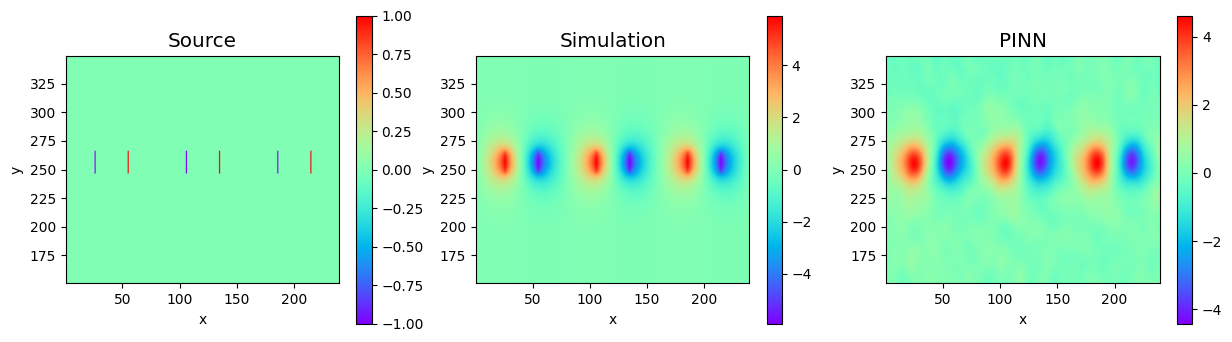

In [61]:
# solve problem
# For block coordinate descent
epochs = 200
block_size = 150 # 10% of 1500 features
key, rng = random.split(rng)

# For block kazmarz
# epochs = 300
# block_size = 500 # set based on GPU VRAM limits
# alpha = 0.001 # learning rate

key, rng = random.split(rng)
# u, ssr, mse, mae, rl2 = compute_ls_ntask(param, key)
u, ssr, mse, mae, rl2 = compute_ls_ntask_bcd(param, key, epochs, block_size)
# u, ssr, mse, mae, rl2 = compute_ls_ntask_kazmarz_batched(param, key, epochs, block_size, alpha)
print('SSR = %.2e  MSE = %.2e  MAE = %.2e  RL2 = %.2e'%(ssr, mse, mae, rl2));

# plot solution
fig = plt.figure(figsize=(15, 4))
ax1 = fig.add_subplot(1,3,1)
s_plot = s.reshape(nx, ny).T 
mesh2 = plt.imshow(s_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
plt.colorbar(mesh2); plt.xlabel('x'); plt.ylabel('y'); plt.title('Source', fontsize='x-large')
ax1 = fig.add_subplot(1,3,2)
s_plot = u_sim.reshape(nx, ny).T 
mesh2 = plt.imshow(s_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
plt.colorbar(mesh2); plt.xlabel('x'); plt.ylabel('y'); plt.title('Simulation', fontsize='x-large')
ax1 = fig.add_subplot(1,3,3)
s_plot = u.reshape(nx, ny).T  
mesh2 = plt.imshow(s_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
plt.colorbar(mesh2); plt.xlabel('x'); plt.ylabel('y'); plt.title('PINN', fontsize='x-large')

Time the run

In [56]:
# _ = compute_ls_ntask(param, key)

In [57]:
#%%timeit -n 10 -r 2
#u, ssr, mse, rl2, mae = compute_ls_ntask(param, key)
#u.block_until_ready()

# Wrong: No block_until_ready() ==> 840 μs ± 17.9 μs per loop (mean ± std. dev. of 2 runs, 10 loops each)